# Exercise 03 - Feature Detection and Matching

In [1]:
# Common setup for Google Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_bgr(img, title="Image", size=(8, 5)):
    """Display a BGR/OpenCV image correctly in notebook."""
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", size=(8, 5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 1: Create two sample images
We generate one image and a rotated/shifted version of the same image, so the notebook works without external files.

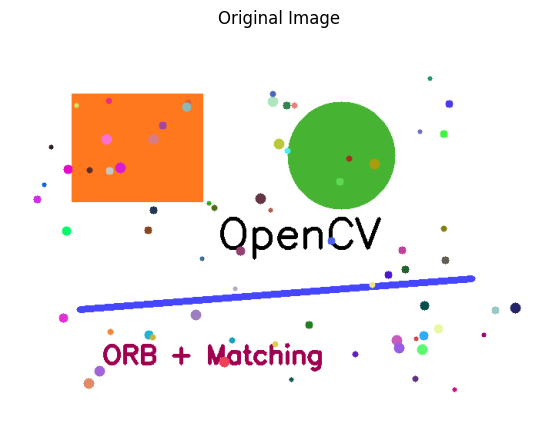

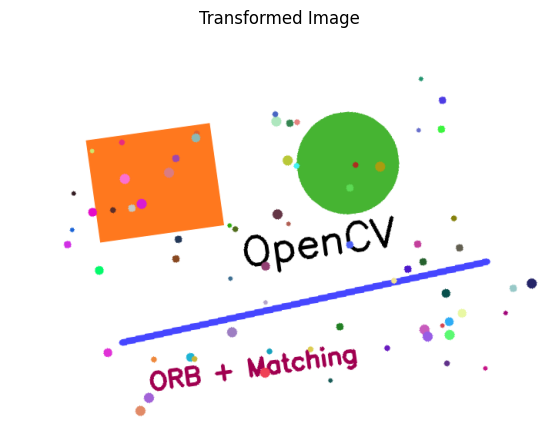

In [2]:

# Create a feature-rich synthetic image
img1 = np.full((500, 700, 3), 255, dtype=np.uint8)

# Draw shapes and text to create corners/features
cv2.rectangle(img1, (80, 80), (250, 220), (30, 120, 255), -1)
cv2.circle(img1, (430, 160), 70, (50, 180, 70), -1)
cv2.line(img1, (90, 360), (600, 320), (255, 70, 70), 8)
cv2.putText(img1, "OpenCV", (270, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 4)
cv2.putText(img1, "ORB + Matching", (120, 430), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (80, 0, 160), 3)

# Add many small circles for more feature points
rng = np.random.default_rng(10)
for x, y in rng.integers([30, 30], [670, 470], size=(70, 2)):
    color = tuple(int(c) for c in rng.integers(0, 255, size=3))
    cv2.circle(img1, (int(x), int(y)), int(rng.integers(3, 8)), color, -1)

# Create a transformed image
angle = 8
scale = 0.95
M = cv2.getRotationMatrix2D((350, 250), angle, scale)
M[:, 2] += [25, 15]
img2 = cv2.warpAffine(img1, M, (700, 500), borderValue=(255, 255, 255))

show_bgr(img1, "Original Image")
show_bgr(img2, "Transformed Image")


## Step 2: Detect ORB features
ORB finds important points like corners and blobs. These keypoints are used for matching.

Keypoints in image 1: 1202
Keypoints in image 2: 1200


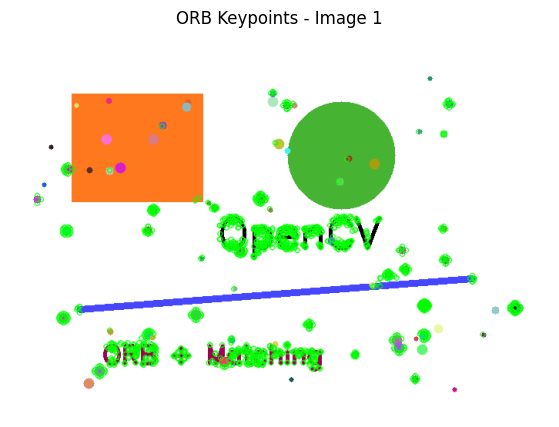

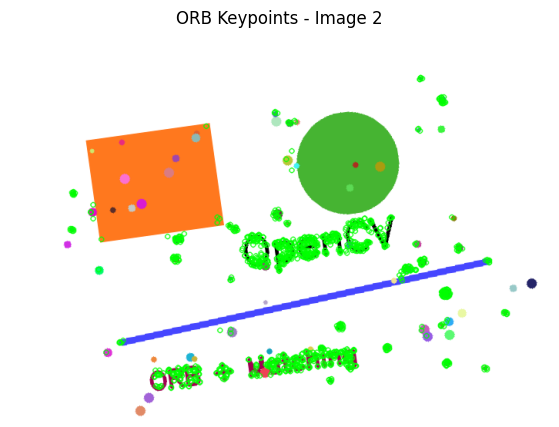

In [3]:

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=1200)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Keypoints in image 1:", len(kp1))
print("Keypoints in image 2:", len(kp2))

kp_img1 = cv2.drawKeypoints(img1, kp1, None, color=(0, 255, 0), flags=0)
kp_img2 = cv2.drawKeypoints(img2, kp2, None, color=(0, 255, 0), flags=0)

show_bgr(kp_img1, "ORB Keypoints - Image 1")
show_bgr(kp_img2, "ORB Keypoints - Image 2")


## Step 3: Match features using Brute Force Matcher
The best matches show similar points between both images.

Total matches: 588
Best 10 match distances: [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


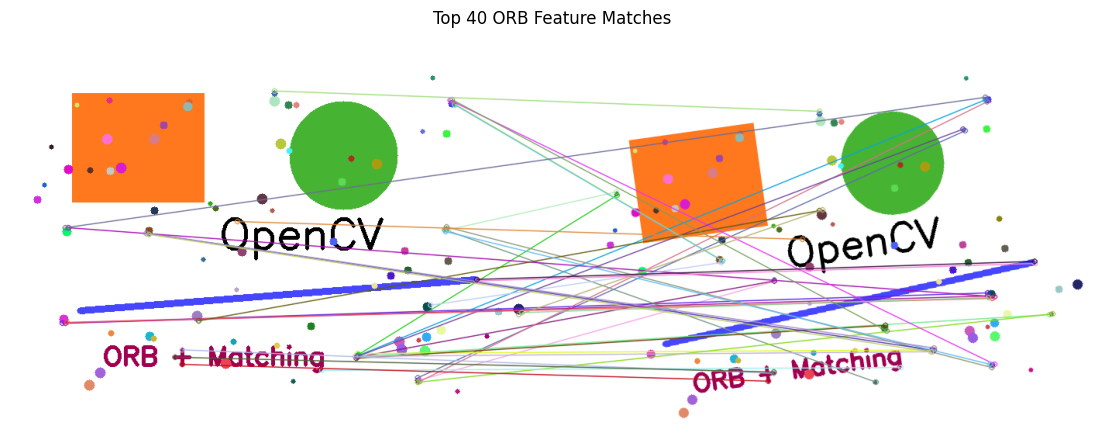

In [4]:

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

print("Total matches:", len(matches))
print("Best 10 match distances:", [round(m.distance, 2) for m in matches[:10]])

matched_img = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

show_bgr(matched_img, "Top 40 ORB Feature Matches", size=(14, 7))


## Step 4: Estimate Homography
Homography uses matched points to align one image with another.

Homography matrix:
 [[ 1.05616366e+00 -1.42072346e-01 -5.77796696e+00]
 [ 1.47257950e-01  1.05433191e+00 -8.26336513e+01]
 [ 7.39975416e-06  1.76474002e-05  1.00000000e+00]]
Inlier matches after RANSAC: 45 / 80


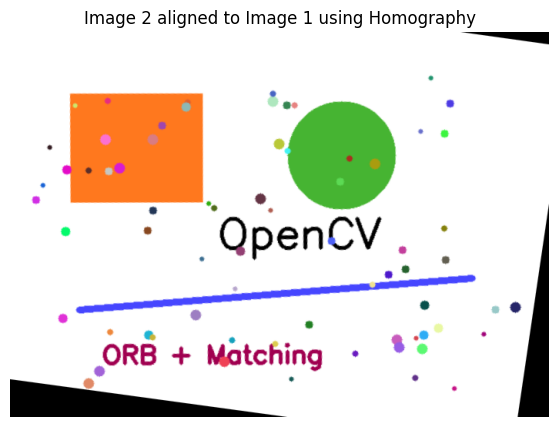

In [5]:

good_matches = matches[:80]

src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
inliers = int(mask.sum()) if mask is not None else 0

print("Homography matrix:\n", H)
print("Inlier matches after RANSAC:", inliers, "/", len(good_matches))

aligned_img2 = cv2.warpPerspective(img2, H, (img1.shape[1], img1.shape[0]))
show_bgr(aligned_img2, "Image 2 aligned to Image 1 using Homography")


## Result
Feature detection found keypoints in both images, matched them, and used RANSAC Homography to align the transformed image.